# Task B3:
Perform image segmentation on the downloaded grayscale image using thresholding by doing the following tasks:
- Display the downloaded grayscale image and its histogram.
- Select two manual threshold values.
- Apply global thresholding for each selected threshold.
- Apply Otsu thresholding.
- Compare the results.

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

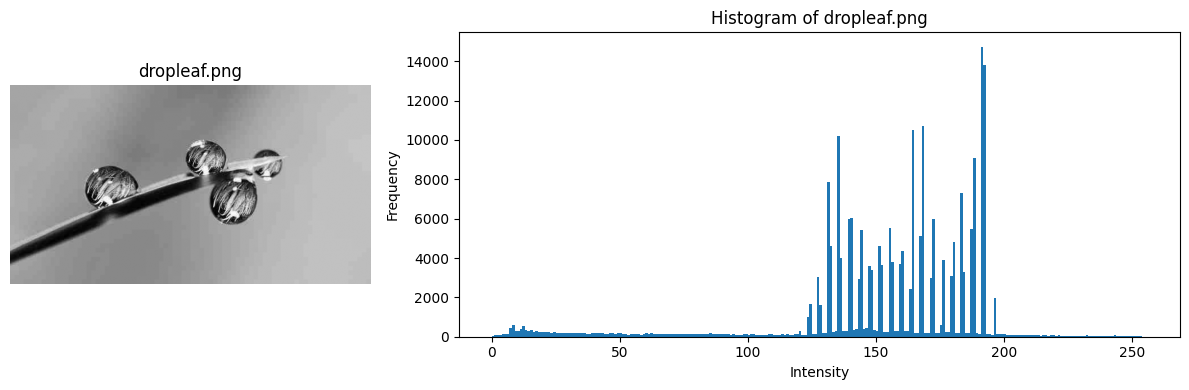

In [15]:
image = cv2.imread("dropleaf.png",0)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    width_ratios=[1, 2]
)

# Image
axes[0].imshow(image, cmap="gray")
axes[0].axis("off")
axes[0].set_title("dropleaf.png")

# Histogram
axes[1].hist(image.ravel(), bins=256, range=[0,256])
axes[1].set_title("Histogram of dropleaf.png")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
threshold_1 = 100
threshold_2 = 200

def global_threshold(image,init_t,limit):
    T=init_t
    while True:
        G_1 = np.array([])
        G_2 = np.array([])
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                pixel=image[i, j]
                if pixel>T:
                    G_1 = np.append(G_1,pixel)
                elif pixel<=T:
                    G_2 = np.append(G_2,pixel)

        if G_1.size > 0: mu_1 = np.mean(G_1)
        else: mu_1 = 0
        if G_2.size > 0: mu_2 = np.mean(G_2)
        else: mu_2 = 0
        new_t = (mu_1 + mu_2)/2

        if abs(T - new_t) < limit:
            T = new_t
            break
        T = new_t
    return T
        
new_threshold_1 = global_threshold(image,threshold_1,1)
new_threshold_2 = global_threshold(image,threshold_2,1)

Global threshold from threshold_1: 103.2145746018392


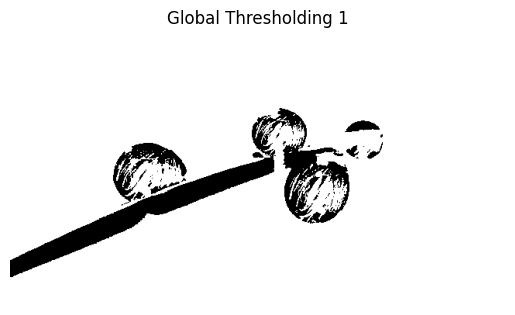

Global threshold from threshold_2: 143.98496140808584


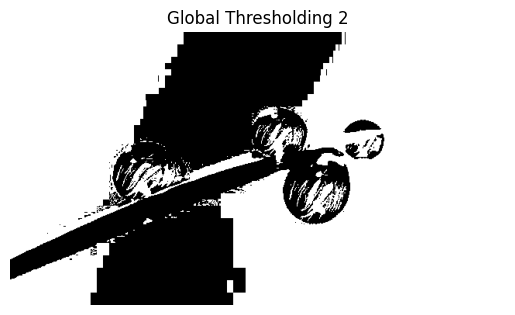

In [18]:
glob_image_1 = image.copy()
glob_image_2 = image.copy()

def thresholding(image,threshold):
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            pixel=image[i, j]
            if pixel>threshold:
                pixel=255
            elif pixel<=threshold:
                pixel=0
            image[i, j]=pixel

thresholding(glob_image_1,new_threshold_1)
thresholding(glob_image_2,new_threshold_2)

print("Global threshold from threshold_1:",new_threshold_1)
plt.imshow(glob_image_1, cmap='gray')
plt.title("Global Thresholding 1")
plt.axis('off')
plt.show()

print("Global threshold from threshold_2:",new_threshold_2)
plt.imshow(glob_image_2, cmap='gray')
plt.title("Global Thresholding 2")
plt.axis('off')
plt.show()

Calculated Otsu threshold value: 103.0


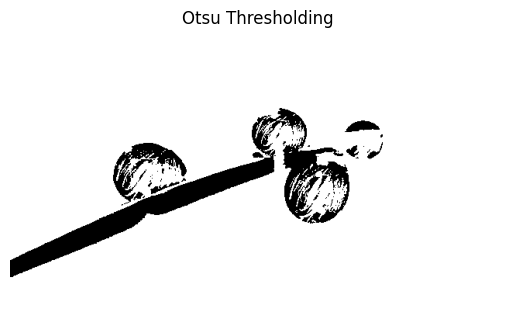

In [13]:
ret, otsu_thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Calculated Otsu threshold value:", ret)

plt.imshow(otsu_thresh, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis('off')
plt.show()